In [2]:
import pandas as pd
import duckdb

# Use DuckDB to peek at the file without loading everything into memory
# Check column names and first few rows
duckdb.sql("""
    SELECT * 
    FROM '../data/postings.csv' 
    LIMIT 5
""").show()

# Check total row count
duckdb.sql("""
    SELECT COUNT(*) as total_jobs 
    FROM '../data/postings.csv'
""").show()

┌──────────┬────────────────────────┬──────────────────────────────────────────────────────────┬────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

In [3]:
# Check for data analyst roles and locations
duckdb.sql("""
    SELECT 
        COUNT(*) as count,
        location
    FROM '../data/postings.csv'
    WHERE LOWER(title) LIKE '%data analyst%'
    GROUP BY location
    ORDER BY count DESC
    LIMIT 20
""").show()

┌───────┬─────────────────────────────────┐
│ count │            location             │
│ int64 │             varchar             │
├───────┼─────────────────────────────────┤
│    57 │ United States                   │
│    12 │ New York, NY                    │
│     8 │ Richmond, VA                    │
│     7 │ Plano, TX                       │
│     7 │ New York City Metropolitan Area │
│     6 │ Atlanta, GA                     │
│     6 │ San Francisco, CA               │
│     6 │ Washington, DC                  │
│     5 │ Austin, TX                      │
│     5 │ San Diego, CA                   │
│     5 │ Orlando, FL                     │
│     5 │ Charlotte, NC                   │
│     5 │ Tampa, FL                       │
│     4 │ Phoenix, AZ                     │
│     4 │ Chicago, IL                     │
│     4 │ Jacksonville, FL                │
│     4 │ Texas, United States            │
│     4 │ Juno Beach, FL                  │
│     4 │ Irving, TX            

In [4]:
# Total data analyst postings
duckdb.sql("""
    SELECT 
        COUNT(*) as total_data_analyst_jobs,
        COUNT(CASE WHEN max_salary IS NOT NULL THEN 1 END) as has_salary,
        COUNT(CASE WHEN skills_desc IS NOT NULL THEN 1 END) as has_skills,
        COUNT(CASE WHEN formatted_experience_level IS NOT NULL THEN 1 END) as has_experience_level
    FROM '../data/postings.csv'
    WHERE LOWER(title) LIKE '%data analyst%'
""").show()

┌─────────────────────────┬────────────┬────────────┬──────────────────────┐
│ total_data_analyst_jobs │ has_salary │ has_skills │ has_experience_level │
│          int64          │   int64    │   int64    │        int64         │
├─────────────────────────┼────────────┼────────────┼──────────────────────┤
│                     408 │        113 │          5 │                  291 │
└─────────────────────────┴────────────┴────────────┴──────────────────────┘



In [5]:
# Expand to related analyst roles
duckdb.sql("""
    SELECT 
        COUNT(*) as total_jobs,
        COUNT(CASE WHEN max_salary IS NOT NULL THEN 1 END) as has_salary,
        COUNT(CASE WHEN formatted_experience_level IS NOT NULL THEN 1 END) as has_experience_level
    FROM '../data/postings.csv'
    WHERE LOWER(title) LIKE '%data analyst%'
       OR LOWER(title) LIKE '%business analyst%'
       OR LOWER(title) LIKE '%business intelligence%'
       OR LOWER(title) LIKE '%data scientist%'
       OR LOWER(title) LIKE '%analytics%'
""").show()

┌────────────┬────────────┬──────────────────────┐
│ total_jobs │ has_salary │ has_experience_level │
│   int64    │   int64    │        int64         │
├────────────┼────────────┼──────────────────────┤
│       1689 │        510 │                 1233 │
└────────────┴────────────┴──────────────────────┘



In [6]:
# Create filtered dataset for analysis
df = duckdb.sql("""
    SELECT 
        job_id,
        company_name,
        title,
        description,
        location,
        min_salary,
        max_salary,
        med_salary,
        pay_period,
        currency,
        formatted_work_type,
        formatted_experience_level,
        remote_allowed,
        skills_desc,
        listed_time
    FROM '../data/postings.csv'
    WHERE LOWER(title) LIKE '%data analyst%'
       OR LOWER(title) LIKE '%business analyst%'
       OR LOWER(title) LIKE '%business intelligence%'
       OR LOWER(title) LIKE '%data scientist%'
       OR LOWER(title) LIKE '%analytics%'
""").df()

# Check shape and preview
print(f"Dataset: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset: 1689 rows, 15 columns


,job_id,company_name,title,description,location,min_salary,max_salary,med_salary,pay_period,currency,formatted_work_type,formatted_experience_level,remote_allowed,skills_desc,listed_time
0,2735151240,LT Apparel Group,Intern- Business Analytics,Summer Internshipadidas & Carhartt kids Divisi...,Greensboro--Winston-Salem--High Point Area,NaN,NaN,NaN,None,None,Temporary,None,NaN,None,1.712862e+12
1,3540371917,KeyBank,Enterprise Data & Analytics Infrastructure Man...,The Enterprise Data Infrastructure and Analyti...,"Cleveland, OH",NaN,NaN,NaN,None,None,Full-time,None,NaN,None,1.713452e+12
2,3780415828,CapAcuity,Technical Business Analyst,We’re actively seeking a Technical Business An...,"Albany, NY",60000.0,80000.0,NaN,YEARLY,USD,Contract,None,NaN,None,1.713468e+12
3,3813645405,Tenazx Inc,Data Analyst,Job Title: Data AnalystDuration: ContractLocat...,"Queens, NY",NaN,NaN,NaN,None,None,Contract,None,NaN,None,1.713465e+12
4,3844031840,Benda Infotech,Junior Business Analyst,Company Description\n Benda Infotech is a tech...,"Chicago, IL",NaN,NaN,NaN,None,None,Full-time,None,NaN,None,1.712858e+12


In [7]:
# Save filtered dataset
df.to_csv('../data/data_analyst_jobs.csv', index=False)
print("Saved to data/data_analyst_jobs.csv")

# Quick overview
print(f"\n--- Job Titles Breakdown ---")
print(df['title'].str.lower().str.extract(r'(data analyst|business analyst|data scientist|business intelligence|analytics)')[0].value_counts())

print(f"\n--- Experience Levels ---")
print(df['formatted_experience_level'].value_counts(dropna=False))

print(f"\n--- Work Types ---")
print(df['formatted_work_type'].value_counts(dropna=False))

Saved to data/data_analyst_jobs.csv

--- Job Titles Breakdown ---
0
business analyst         553
data analyst             407
analytics                354
data scientist           246
business intelligence    129
Name: count, dtype: int64

--- Experience Levels ---
formatted_experience_level
Mid-Senior level    761
None                456
Entry level         230
Associate           143
Director             62
Internship           26
Executive            11
Name: count, dtype: int64

--- Work Types ---
formatted_work_type
Full-time     1171
Contract       456
Part-time       26
Internship      21
Temporary        8
Other            6
Volunteer        1
Name: count, dtype: int64


In [8]:
# Salary analysis
import numpy as np

# Filter rows with salary data and yearly pay
salary_df = df[
    (df['max_salary'].notna()) & 
    (df['pay_period'] == 'YEARLY')
].copy()

print(f"Jobs with yearly salary data: {len(salary_df)}")

# Calculate midpoint salary where missing
salary_df['salary'] = salary_df['med_salary'].fillna(
    (salary_df['min_salary'] + salary_df['max_salary']) / 2
)

# Salary by role type
salary_df['role_type'] = salary_df['title'].str.lower().str.extract(
    r'(data analyst|business analyst|data scientist|business intelligence|analytics)'
)[0]

print("\n--- Median Salary by Role ---")
print(salary_df.groupby('role_type')['salary'].median().sort_values(ascending=False).apply(lambda x: f"${x:,.0f}"))

print("\n--- Median Salary by Experience Level ---")
print(salary_df.groupby('formatted_experience_level')['salary'].median().sort_values(ascending=False).apply(lambda x: f"${x:,.0f}"))

Jobs with yearly salary data: 369

--- Median Salary by Role ---
role_type
data scientist           $162,200
analytics                $145,000
business intelligence    $122,162
business analyst         $102,000
data analyst              $95,000
Name: salary, dtype: object

--- Median Salary by Experience Level ---
formatted_experience_level
Executive           $222,500
Director            $205,000
Mid-Senior level    $125,102
Entry level         $105,200
Associate            $93,059
Internship           $80,000
Name: salary, dtype: object


In [9]:
# Extract skills from job descriptions
from collections import Counter

# Define skills to look for
skills = [
    'python', 'sql', 'excel', 'tableau', 'power bi', 'r programming', ' r,', ' r ',
    'sas', 'spss', 'matlab', 'spark', 'hadoop', 'aws', 'azure', 'gcp', 'snowflake',
    'redshift', 'bigquery', 'dbt', 'airflow', 'git', 'jupyter', 'pandas', 'numpy',
    'scikit-learn', 'tensorflow', 'pytorch', 'machine learning', 'deep learning',
    'statistics', 'a/b testing', 'etl', 'data warehouse', 'looker', 'dax',
    'powerpoint', 'communication', 'stakeholder', 'visualization', 'dashboards'
]

# Count skills in descriptions
skill_counts = Counter()
total_jobs = len(df)

for desc in df['description'].dropna().str.lower():
    for skill in skills:
        if skill in desc:
            # Normalize skill name
            clean_skill = skill.strip().strip(',').upper()
            if clean_skill == 'R' or skill in [' r,', ' r ']:
                clean_skill = 'R'
            skill_counts[clean_skill] += 1

# Convert to percentages
print("--- Top 20 Skills (% of job postings mentioning) ---\n")
for skill, count in skill_counts.most_common(20):
    pct = (count / total_jobs) * 100
    print(f"{skill:<20} {pct:>5.1f}%  {'█' * int(pct/2)}")

--- Top 20 Skills (% of job postings mentioning) ---

EXCEL                 59.1%  █████████████████████████████
COMMUNICATION         54.8%  ███████████████████████████
SQL                   48.4%  ████████████████████████
STAKEHOLDER           46.1%  ███████████████████████
PYTHON                33.6%  ████████████████
VISUALIZATION         24.2%  ████████████
STATISTICS            20.9%  ██████████
TABLEAU               20.4%  ██████████
GIT                   19.9%  █████████
DASHBOARDS            19.2%  █████████
AWS                   18.6%  █████████
MACHINE LEARNING      17.1%  ████████
R                     14.6%  ███████
POWER BI              14.0%  ██████
SAS                   13.4%  ██████
POWERPOINT            10.5%  █████
DATA WAREHOUSE         7.5%  ███
ETL                    7.2%  ███
AZURE                  7.1%  ███
SPARK                  6.7%  ███


In [12]:
# Skills by role type
def get_skills(text):
    if pd.isna(text):
        return []
    text = text.lower()
    found = []
    for skill in ['excel', 'sql', 'python', 'tableau', 'power bi', 'r', 
                  'machine learning', 'aws', 'statistics', 'communication']:
        if skill in text:
            found.append(skill.upper())
    return found

df['role_type'] = df['title'].str.lower().str.extract(
    r'(data analyst|business analyst|data scientist|business intelligence|analytics)'
)[0]

# Build comparison
role_skills = {}
for role in ['data analyst', 'data scientist', 'business analyst']:
    role_df = df[df['role_type'] == role]
    total = len(role_df)
    skills_count = Counter()
    for desc in role_df['description'].dropna().str.lower():
        for skill in ['excel', 'sql', 'python', 'tableau', 'power bi', 
                      'machine learning', 'aws', 'statistics', 'r']:
            if skill in desc:
                skills_count[skill.upper()] += 1
    role_skills[role] = {k: round(v/total*100, 1) for k, v in skills_count.items()}

# Display comparison
import pandas as pd
comparison = pd.DataFrame(role_skills).T
comparison = comparison[['SQL', 'PYTHON', 'EXCEL', 'TABLEAU', 'MACHINE LEARNING', 'AWS', 'STATISTICS']]
print("--- Skill Requirements by Role (% of postings) ---\n")
print(comparison.to_string())

--- Skill Requirements by Role (% of postings) ---

                   SQL  PYTHON  EXCEL  TABLEAU  MACHINE LEARNING   AWS  STATISTICS
data analyst      64.6    35.9   63.1     21.9              13.3  16.2        21.6
data scientist    62.2    88.2   53.3     18.7              71.5  34.6        63.4
business analyst  24.4     5.4   58.0      6.7               1.1  10.7         3.4


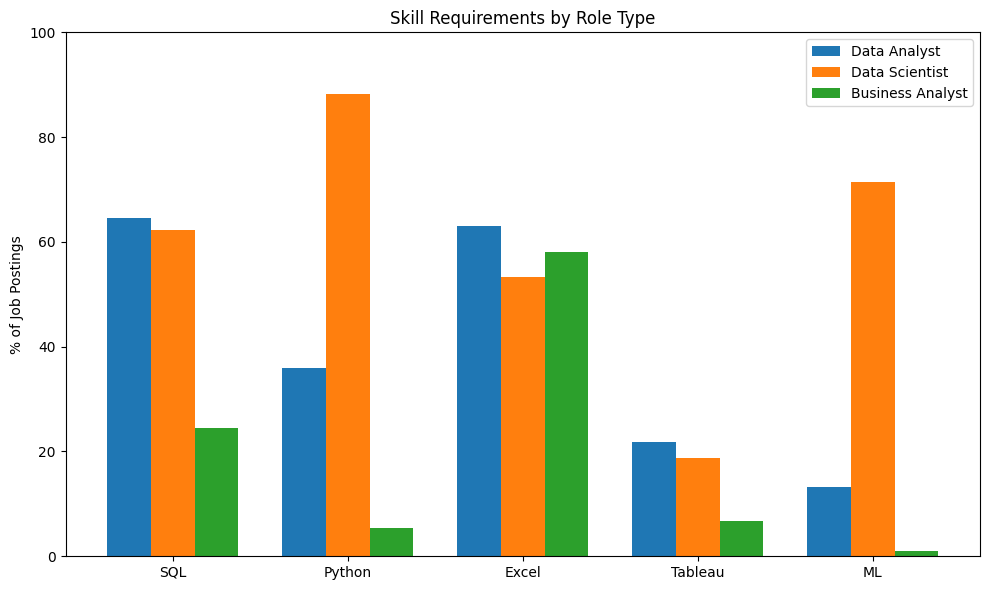


Saved to outputs/skills_by_role.png


In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Build comparison from actual data
skills_to_track = ['sql', 'python', 'excel', 'tableau', 'machine learning']
roles = ['data analyst', 'data scientist', 'business analyst']

roles_data = {}
for role in roles:
    role_df = df[df['role_type'] == role]
    total = len(role_df)
    role_data = {}
    for skill in skills_to_track:
        count = role_df['description'].dropna().str.lower().str.contains(skill).sum()
        role_data[skill.upper().replace('MACHINE LEARNING', 'ML')] = round(count/total*100, 1)
    roles_data[role.title()] = role_data

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(skills_to_track))
width = 0.25
skill_labels = ['SQL', 'PYTHON', 'EXCEL', 'TABLEAU', 'MACHINE LEARNING']

for i, (role, data) in enumerate(roles_data.items()):
    values = [data.get(s.upper().replace('MACHINE LEARNING', 'ML'), 0) for s in skill_labels]
    ax.bar(x + i*width, values, width, label=role)

ax.set_ylabel('% of Job Postings')
ax.set_title('Skill Requirements by Role Type')
ax.set_xticks(x + width)
ax.set_xticklabels(['SQL', 'Python', 'Excel', 'Tableau', 'ML'])
ax.legend()
ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('../outputs/skills_by_role.png', dpi=150)
plt.show()
print("\nSaved to outputs/skills_by_role.png")

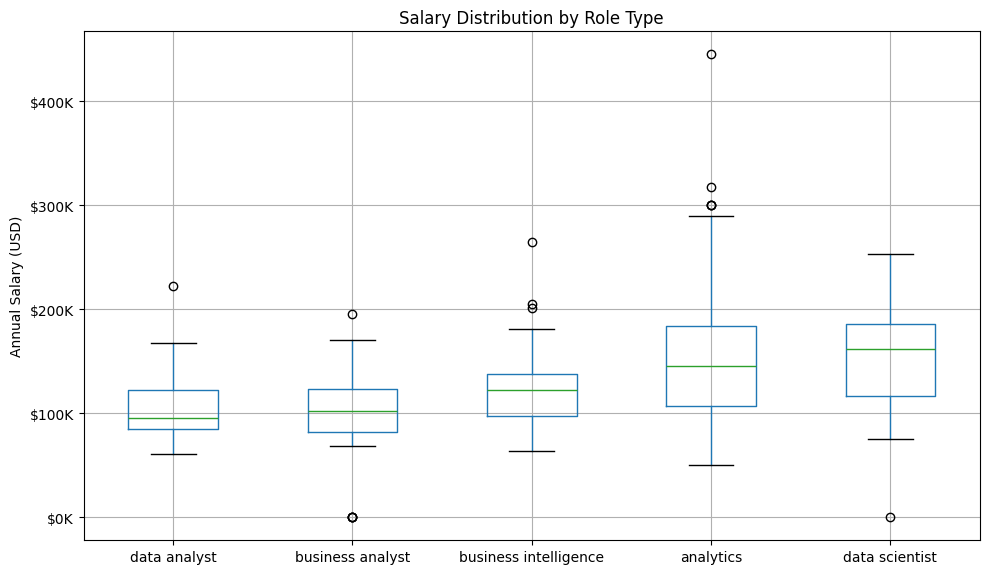


Saved to outputs/salary_by_role.png


In [14]:
# Salary distribution by role
fig, ax = plt.subplots(figsize=(10, 6))

salary_df_clean = salary_df[salary_df['role_type'].notna()].copy()

roles_order = ['data analyst', 'business analyst', 'business intelligence', 'analytics', 'data scientist']
colors = ['#1f77b4', '#2ca02c', '#9467bd', '#ff7f0e', '#d62728']

salary_df_clean['role_type'] = pd.Categorical(
    salary_df_clean['role_type'], 
    categories=roles_order, 
    ordered=True
)

salary_df_clean.boxplot(column='salary', by='role_type', ax=ax)
ax.set_ylabel('Annual Salary (USD)')
ax.set_xlabel('')
ax.set_title('Salary Distribution by Role Type')
plt.suptitle('')  # Remove automatic title

# Format y-axis as currency
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

plt.tight_layout()
plt.savefig('../outputs/salary_by_role.png', dpi=150)
plt.show()
print("\nSaved to outputs/salary_by_role.png")

In [16]:
# Entry-level analysis
entry_level = df[df['formatted_experience_level'] == 'Entry level'].copy()
print(f"Entry-level jobs: {len(entry_level)}")

# Role breakdown
print("\n--- Entry Level by Role Type ---")
print(entry_level['role_type'].value_counts())

# Skills for entry-level data analyst
entry_da = entry_level[entry_level['role_type'] == 'data analyst']
print(f"\n--- Skills for Entry-Level Data Analysts ({len(entry_da)} jobs) ---\n")

skills_to_check = ['sql', 'python', 'excel', 'tableau', 'power bi', 
                   'machine learning', 'statistics', 'communication']

for skill in skills_to_check:
    count = entry_da['description'].dropna().str.lower().str.contains(skill).sum()
    pct = count / len(entry_da) * 100
    print(f"{skill.upper():<18} {pct:>5.1f}%  {'█' * int(pct/3)}")

Entry-level jobs: 230

--- Entry Level by Role Type ---
role_type
data analyst             116
data scientist            58
analytics                 30
business analyst          21
business intelligence      5
Name: count, dtype: int64

--- Skills for Entry-Level Data Analysts (116 jobs) ---

SQL                 37.1%  ████████████
PYTHON              20.7%  ██████
EXCEL               44.8%  ██████████████
TABLEAU             12.9%  ████
POWER BI            11.2%  ███
MACHINE LEARNING    29.3%  █████████
STATISTICS          18.1%  ██████
COMMUNICATION       31.0%  ██████████


In [17]:
# Save key findings
summary = """
# Data Analyst Job Market Analysis - Key Findings

## Dataset
- 1,689 data-related job postings from LinkedIn
- 369 with salary data, 230 entry-level positions

## Salary Insights
- Data Analyst median: $95,000
- Data Scientist median: $162,200
- Entry-level median: $105,200

## Most In-Demand Skills (Overall)
1. Excel (59%)
2. Communication (55%)
3. SQL (48%)
4. Stakeholder Management (46%)
5. Python (34%)

## Entry-Level Data Analyst Requirements
1. Excel (45%)
2. SQL (37%)
3. Communication (31%)
4. Python (21%)
5. Tableau (13%)

## Key Insight
Data Analyst roles are less technical than expected. 
Excel + SQL + communication skills cover most job requirements.
Python and ML differentiate you, but aren't required for entry-level.
"""

with open('../outputs/key_findings.md', 'w') as f:
    f.write(summary)

print(summary)
print("\nSaved to outputs/key_findings.md")


# Data Analyst Job Market Analysis - Key Findings

## Dataset
- 1,689 data-related job postings from LinkedIn
- 369 with salary data, 230 entry-level positions

## Salary Insights
- Data Analyst median: $95,000
- Data Scientist median: $162,200
- Entry-level median: $105,200

## Most In-Demand Skills (Overall)
1. Excel (59%)
2. Communication (55%)
3. SQL (48%)
4. Stakeholder Management (46%)
5. Python (34%)

## Entry-Level Data Analyst Requirements
1. Excel (45%)
2. SQL (37%)
3. Communication (31%)
4. Python (21%)
5. Tableau (13%)

## Key Insight
Data Analyst roles are less technical than expected. 
Excel + SQL + communication skills cover most job requirements.
Python and ML differentiate you, but aren't required for entry-level.


Saved to outputs/key_findings.md
